**ABHIJTI SARKAR**
(MODULE 2 - PAPER 1)
DATE:- 30/05/2026

DATA SET 1 - **Refurbished_cars**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cars = pd.read_csv("/content/drive/MyDrive/DBA/MODULE 2 PAPER 1/Refurbished_cars_Paper1.csv")

In [ ]:
cars

,Car_ID,Brand,Year,Kilometers_Driven,Fuel_Type,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,2018,50000,Petrol,First,15,1498,108,5,800000
1,2,Honda,2019,40000,Petrol,Second,17,1597,140,5,1000000
2,3,Ford,2017,20000,Petrol,First,10,4951,395,4,2500000
3,4,Maruti,2020,30000,Diesel,Third,23,1248,74,5,600000
4,5,Hyundai,2016,60000,Diesel,Second,18,1999,194,5,850000
...,...,...,...,...,...,...,...,...,...,...,...
95,96,Mercedes,2019,22000,Diesel,First,16,1950,191,5,2900000
96,97,Toyota,2017,38000,Diesel,Second,13,2755,171,7,1400000
97,98,Ford,2018,26000,Petrol,Third,18,1497,121,5,750000
98,99,Hyundai,2019,24000,Petrol,Second,17,1497,113,5,850000


In [ ]:
cars = cars.drop("Car_ID", axis=1)

In [ ]:
cars

,Brand,Year,Kilometers_Driven,Fuel_Type,Owner_Type,Mileage,Engine,Power,Seats,Price
0,Toyota,2018,50000,Petrol,First,15,1498,108,5,800000
1,Honda,2019,40000,Petrol,Second,17,1597,140,5,1000000
2,Ford,2017,20000,Petrol,First,10,4951,395,4,2500000
3,Maruti,2020,30000,Diesel,Third,23,1248,74,5,600000
4,Hyundai,2016,60000,Diesel,Second,18,1999,194,5,850000
...,...,...,...,...,...,...,...,...,...,...
95,Mercedes,2019,22000,Diesel,First,16,1950,191,5,2900000
96,Toyota,2017,38000,Diesel,Second,13,2755,171,7,1400000
97,Ford,2018,26000,Petrol,Third,18,1497,121,5,750000
98,Hyundai,2019,24000,Petrol,Second,17,1497,113,5,850000


In [ ]:
#Dataset Information
print(cars.head())
print(cars.info())
print(cars.describe())

     Brand  Year  Kilometers_Driven Fuel_Type Owner_Type  Mileage  Engine  \
0   Toyota  2018              50000    Petrol      First       15    1498   
1    Honda  2019              40000    Petrol     Second       17    1597   
2     Ford  2017              20000    Petrol      First       10    4951   
3   Maruti  2020              30000    Diesel      Third       23    1248   
4  Hyundai  2016              60000    Diesel     Second       18    1999   

   Power  Seats    Price  
0    108      5   800000  
1    140      5  1000000  
2    395      4  2500000  
3     74      5   600000  
4    194      5   850000  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Brand              100 non-null    object
 1   Year               100 non-null    int64 
 2   Kilometers_Driven  100 non-null    int64 
 3   Fuel_Type          100 non-null

In [ ]:
# Check missing values
print(cars.isnull().sum())

Brand                0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Price                0
dtype: int64


In [ ]:
#Converting Categorical Variables into Numeric
le = LabelEncoder()

cars["Brand"] = le.fit_transform(cars["Brand"])
cars["Fuel_Type"] = le.fit_transform(cars["Fuel_Type"])
cars["Owner_Type"] = le.fit_transform(cars["Owner_Type"])

In [ ]:
print(cars.head())

   Brand  Year  Kilometers_Driven  Fuel_Type  Owner_Type  Mileage  Engine  \
0      9  2018              50000          1           0       15    1498   
1      3  2019              40000          1           1       17    1597   
2      2  2017              20000          1           0       10    4951   
3      6  2020              30000          0           2       23    1248   
4      4  2016              60000          0           1       18    1999   

   Power  Seats    Price  
0    108      5   800000  
1    140      5  1000000  
2    395      4  2500000  
3     74      5   600000  
4    194      5   850000  


In [ ]:
# Define Features and Target Variable
X = cars.drop("Price", axis=1)
Y = cars["Price"]


In [ ]:
print(X.head())
print(Y.head())

   Brand  Year  Kilometers_Driven  Fuel_Type  Owner_Type  Mileage  Engine  \
0      9  2018              50000          1           0       15    1498   
1      3  2019              40000          1           1       17    1597   
2      2  2017              20000          1           0       10    4951   
3      6  2020              30000          0           2       23    1248   
4      4  2016              60000          0           1       18    1999   

   Power  Seats  
0    108      5  
1    140      5  
2    395      4  
3     74      5  
4    194      5  
0     800000
1    1000000
2    2500000
3     600000
4     850000
Name: Price, dtype: int64


In [ ]:
# Split Dataset into Training and Testing Data
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(80, 9)
(20, 9)


In [ ]:
# Build Multiple Linear Regression Model
model = LinearRegression()

model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)


In [ ]:
# Evaluate Model Performance
print("Model Performance")

print("Mean Absolute Error (MAE):",
      mean_absolute_error(Y_test, Y_pred))

print("Mean Squared Error (MSE):",
      mean_squared_error(Y_test, Y_pred))

print("R2 Score:",
      r2_score(Y_test, Y_pred))


Model Performance
Mean Absolute Error (MAE): 390612.73968756647
Mean Squared Error (MSE): 221839404235.52792
R2 Score: 0.7287529446285652


In [ ]:
# Display Regression Coefficients
print("Intercept:")
print(model.intercept_)

print("Coefficients:")
print(model.coef_)

Intercept:
257821231.61756393
Coefficients:
[-2.53585407e+04 -1.26840417e+05 -2.17402225e+01 -5.11086476e+05
 -9.33873995e+04 -4.34028526e+04 -3.09999926e+02  1.04776218e+04
  9.82689289e+04]


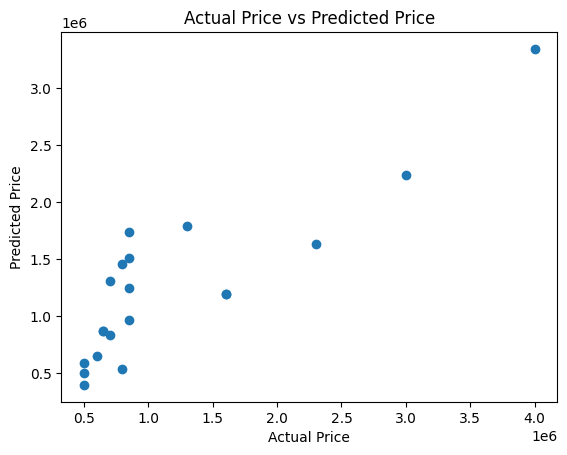

In [ ]:
# Visualization
plt.scatter(Y_test, Y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")

plt.show()

The target variable is Price, which is numerical, so Regression was selected.
Linear Regression and Regression Coefficients were applied.
Model performance was evaluated using MAE, MSE, and R² Score.

DATA SET 2 - **Concrete**

In [ ]:
con = pd.read_csv("/content/drive/MyDrive/DBA/MODULE 2 PAPER 1/Concrete_Paper1.csv")

In [ ]:
con

,Cement,Slag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,ConcreteStrength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [ ]:
# Missing Values
print(con.isnull().sum())

Cement               0
Slag                 0
FlyAsh               0
Water                0
Superplasticizer     0
CoarseAggregate      0
FineAggregate        0
Age                  0
ConcreteStrength     0
dtype: int64


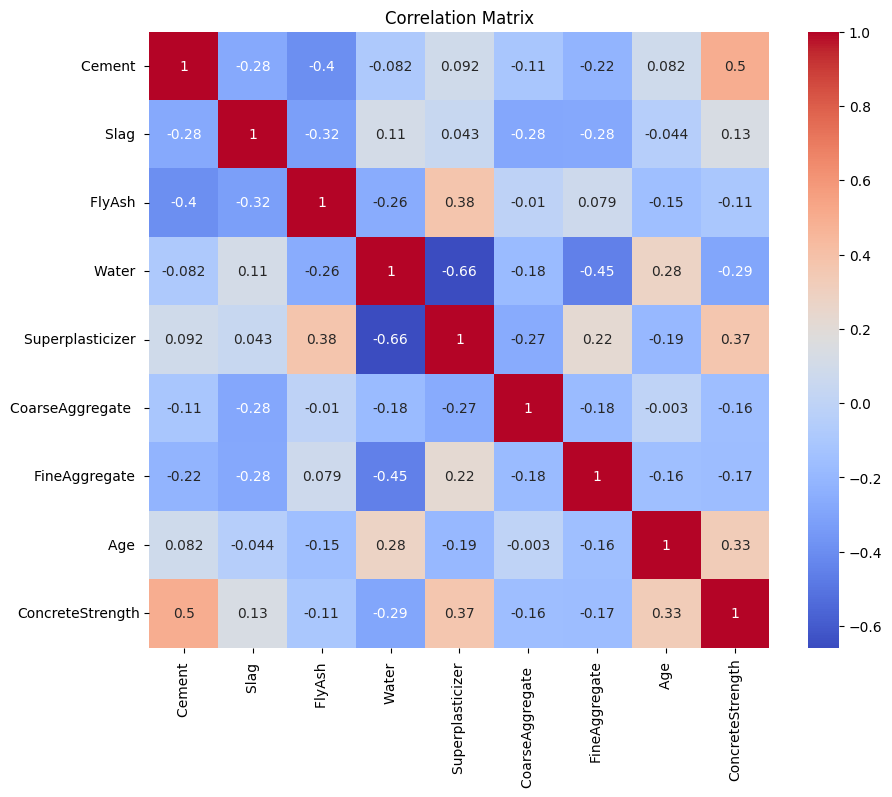

In [ ]:
# CORRELATION HEATMAP
plt.figure(figsize=(10,8))

sns.heatmap(
    con.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
# DEFINE FEATURES AND TARGET
X = con.iloc[:, :-1]
Y = con.iloc[:, -1]

In [ ]:
print(X.head())
print(Y.head())

   Cement   Slag   FlyAsh   Water   Superplasticizer   CoarseAggregate    \
0    540.0    0.0      0.0   162.0                2.5             1040.0   
1    540.0    0.0      0.0   162.0                2.5             1055.0   
2    332.5  142.5      0.0   228.0                0.0              932.0   
3    332.5  142.5      0.0   228.0                0.0              932.0   
4    198.6  132.4      0.0   192.0                0.0              978.4   

   FineAggregate   Age   
0           676.0    28  
1           676.0    28  
2           594.0   270  
3           594.0   365  
4           825.5   360  
0    79.99
1    61.89
2    40.27
3    41.05
4    44.30
Name: ConcreteStrength, dtype: float64


In [ ]:
# TRAIN TEST SPLIT
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)


(824, 8)
(206, 8)


In [ ]:
# LINEAR REGRESSION
lr = LinearRegression()

lr.fit(X_train, Y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression")

print("MAE :", mean_absolute_error(Y_test, lr_pred))

print("RMSE :", np.sqrt(
    mean_squared_error(Y_test, lr_pred)
))

print("R2 Score :", r2_score(
  Y_test,
    lr_pred
))


Linear Regression
MAE : 7.745559243921434
RMSE : 9.796475901624358
R2 Score : 0.627553179231485


In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# RANDOM FOREST REGRESSOR
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, Y_train)

rf_pred = rf.predict(X_test)

print(" Random Forest ")

print("MAE :", mean_absolute_error(Y_test, rf_pred))

print("RMSE :", np.sqrt(
    mean_squared_error(Y_test, rf_pred)
))

print("R2 Score :", r2_score(
  Y_test,
    rf_pred
))

 Random Forest 
MAE : 3.736334329056867
RMSE : 5.463919574755465
R2 Score : 0.8841401081258502


In [ ]:
# FEATURE IMPORTANCE
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance")
print(importance)

Feature Importance
             Feature  Importance
7               Age     0.333812
0            Cement     0.325029
3             Water     0.126405
1              Slag     0.077405
4  Superplasticizer     0.056133
6     FineAggregate     0.035130
5  CoarseAggregate      0.028127
2            FlyAsh     0.017960


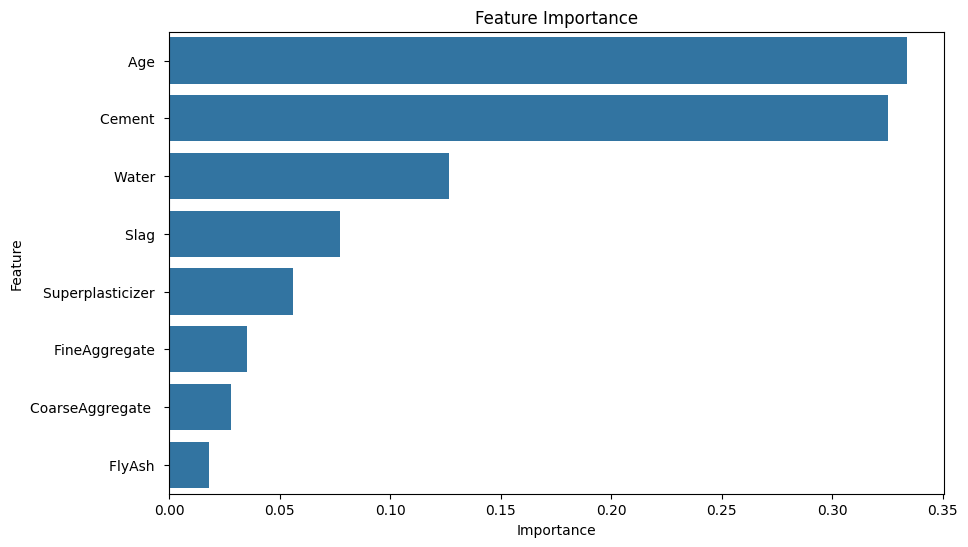

In [ ]:
# VISUALIZE FEATURE IMPORTANCE
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")
plt.show()

Rationale:
Linear Regression was selected because Concrete Compressive Strength is a continuous numerical variable that needs to be predicted.

Outcome:
The model predicts concrete strength based on the input ingredients. Performance was evaluated using MAE, RMSE, and R² Score.